In [1]:
import numpy as np 
import h5py 
from pathlib import Path

In [2]:
path = "/om4/group/mcdermott/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets" 

In [3]:
!ls {path}

train_DZKGBOFKNVV2SVR5ZNV7KC5TRMD6P5ZJ	valid_RQTTZB4C3TJJVLJUWDV72TYMC7S4MNHH


In [4]:
file = list(Path(path, 'train_DZKGBOFKNVV2SVR5ZNV7KC5TRMD6P5ZJ').glob('*.h5'))[0].as_posix()

In [5]:
sounds = h5py.File(file, 'r')

In [6]:
sounds.keys()

<KeysViewHDF5 ['config', 'hash', 'meta', 'sources', 'stimuli']>

In [21]:
sounds['sources']['signal'].keys()

<KeysViewHDF5 ['corpus', 'corpus_int', 'duration_ms_parent_signal', 'end_ms_word', 'parent_loc_index', 'path', 'path_int', 'signal', 'signal_inds', 'source', 'source_int', 'speaker', 'speaker_int', 'sr', 'start_ms_word', 'word', 'word_int']>

In [7]:
speakers = sounds['sources']['signal']['speaker']

In [8]:
speech = sounds['sources']['signal']['signal']

In [12]:
noise = sounds['sources']['noise']['signal']

In [9]:
speech

<HDF5 dataset "signal": shape (29053, 40000), type "<f4">

In [10]:
speech[:2,:]

array([[ 2.4309835 , -0.28791863, -1.4427233 , ...,  0.08301184,
         0.09132863,  0.0983055 ],
       [ 0.7698452 ,  0.8690367 ,  0.88614404, ..., -0.26905704,
        -0.23007312, -0.155794  ]], dtype=float32)

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

from IPython.display import Audio

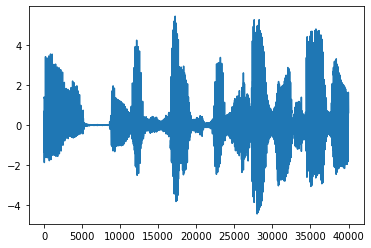

In [62]:
target_ix = 100

plt.plot(speech[target_ix]);

In [63]:
Audio(speech[target_ix], rate=20000)

In [64]:
talker = speakers[target_ix]
speech_excerpt  = speech[target_ix]

In [65]:
good_ixs = np.where(speakers[:] == talker)[0]

In [66]:
good_ixs

array([   38,    71,   100,   193,   231,   260,   354,   650,   675,
         918,   929,   974,  1101,  1135,  1240,  1351,  1362,  1729,
        1787,  1946,  2022,  2232,  2632,  2770,  3033,  3046,  3067,
        3159,  3635,  3671,  3810,  4051,  4201,  4448,  4653,  4821,
        4972,  5014,  5065,  5136,  5431,  5492,  5549,  5578,  5657,
        5670,  5975,  6363,  6494,  6564,  6838,  6842,  6995,  7031,
        7146,  7299,  7335,  7475,  7499,  7701,  8064,  8088,  8241,
        8543,  8698,  8717,  8753,  8770,  8866,  9263,  9532,  9672,
        9780, 10139, 10182, 10340, 10622, 10908, 11113, 11489, 11501,
       11882, 11898, 12100, 12277, 12307, 12358, 12520, 12620, 12782,
       13152, 13212, 13215, 13288, 13300, 13579, 13627, 13832, 13850,
       13870, 14035, 14560, 14652, 14875, 15284, 15550, 15573, 15890,
       16060, 16374, 16487, 16539, 16592, 16694, 16700, 16924, 17089,
       17228, 17249, 17385, 17881, 17962, 18281, 18283, 18321, 18402,
       18504, 18605,

In [67]:
other_signal = speech[good_ixs[10]]

In [68]:
Audio(other_signal, rate=20000)

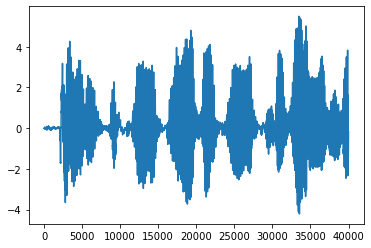

In [69]:
plt.plot(other_signal)

In [70]:
window_duration = int(.5 * 20000)

In [71]:
window_duration

10000

In [40]:
np.random.seed(1)
rms = lambda x: np.sqrt(np.mean(x**2))

rms_of_signal = rms(other_signal)

threshold = .5 * rms_of_signal

start_ix = np.random.randint(int(len(other_signal) * .75))

cue = other_signal[start_ix: start_ix + window_duration]

while rms(cue) < threshold:
    start_ix = np.random.randint(len(other_signal) - int(len(other_signal) * .75))
    cue = other_signal[start_ix: start_ix + window_duration]



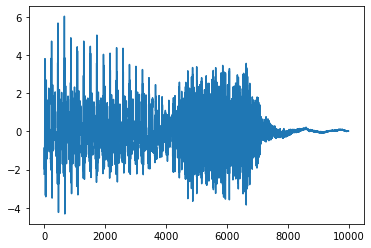

In [41]:
plt.plot(cue)

In [42]:
Audio(cue, rate=20000)

In [43]:
other_talker_ixs = np.where(speakers[:] != talker)[0]

other_voice_ix = np.random.choice(other_talker_ixs)
other_talker = speakers[other_voice_ix]
other_speech = speech[other_voice_ix]

In [45]:
other_talker

b'theroachyjay'

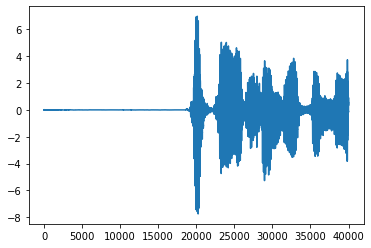

In [44]:
plt.plot(other_speech)

In [46]:
Audio(other_speech, rate=20000)

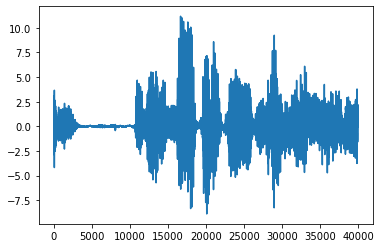

In [52]:
def demean(x):
    return x - x.mean()

foreground_wav = speech_excerpt
background_wav = other_speech

ratio = 0
rms_ratio = np.power(10.0, ratio / 20.0)
# Demean signal and noise before computing rms
foreground_wav = demean(foreground_wav)
background_wav = demean(background_wav)

rms_foreground = rms(foreground_wav)
rms_background = rms(background_wav)

if rms_foreground == 0: # No foreground condition (just noise)
    noise_scale_factor = 1
elif rms_background == 0:
    noise_scale_factor = 0
else:
    noise_scale_factor = rms_foreground / (rms_background * rms_ratio)
                                
background_wav = noise_scale_factor * background_wav
mixture = foreground_wav + background_wav

plt.plot(mixture);

In [54]:
Audio(cue, rate=20000)

In [53]:
Audio(mixture, rate=20000)